# 数据预处理（data_preprocessing.ipynb）

本 notebook 包含：数据读取、清洗、血压拆分、心电/超声描述合并、基础探索性分析（风险分布、血压散点图）以及将中间产物保存为 CSV。

In [35]:
# 导入库
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [36]:
# 读取数据（若需要改路径请修改）
path = 'dataset_demo.csv'
try:
    df = pd.read_csv(path, encoding='gbk')
except Exception:
    df = pd.read_csv(path, encoding='utf-8', errors='ignore')
df = df.dropna(how='all')
print('读取完成，形状：', df.shape)
df.head()

读取完成，形状： (300, 18)


,Unnamed: 0,序号,性别,年龄,右侧血压（mmHg）,身高,体重,腰围,体质指数,吸烟状况,饮酒频率,空腹血糖MMOL,心电图异常描述,总胆固醇,甘油三酯,血清低密度脂蛋白胆固醇,血淸高密度脂蛋白胆固醇,B超
0,109,112,男,35,114/67,166.0,65.4,80,23.73,吸烟,偶尔,5.5,正常,3.34,0.88,1.34,2.44,正常
1,126,130,男,35,123/75,165.5,60.1,75,21.94,从不吸烟,从不,3.0,正常,3.77,0.75,0.64,3.87,正常
2,66,67,男,35,75/37,169.0,63.2,75,22.13,吸烟,从不,5.1,心动过缓,3.08,0.48,1.11,2.09,正常
3,220,224,男,36,107/59,168.0,88.4,96,31.32,已戒烟,偶尔,5.1,正常,2.10,0.00,2.40,1.03,脂肪肝
4,98,101,男,35,130/70,170.5,62.0,79,21.33,从不吸烟,从不,3.9,正常,3.59,1.39,1.06,3.04,正常


In [37]:
# 查找并拆分血压列（形如 '120/80'）
bp_cols = [c for c in df.columns if '血压' in str(c) or 'mmHg' in str(c) or 'mmhg' in str(c)]
if len(bp_cols)==0:
    bp_cols = [c for c in df.columns if df[c].astype(str).str.contains('/').any()]
bp_col = bp_cols[0] if bp_cols else None
print('找到血压列:', bp_col)
if bp_col:
    df[['右侧收缩压','右侧舒张压']] = df[bp_col].astype(str).str.split('/', expand=True)
    df['右侧收缩压'] = pd.to_numeric(df['右侧收缩压'], errors='coerce')
    df['右侧舒张压'] = pd.to_numeric(df['右侧舒张压'], errors='coerce')
df[['右侧收缩压','右侧舒张压']].head()

找到血压列: 右侧血压（mmHg）


,右侧收缩压,右侧舒张压
0,114,67
1,123,75
2,75,37
3,107,59
4,130,70


In [38]:
# 合并心电图与超声描述的简化函数
def merge_ecg_description(x):
    if pd.isna(x):
        return 'NA'
    s = str(x)
    if 'T' in s or 'ST' in s or 'T波' in s:
        return 'ST异常'
    if '过缓' in s or '缓' in s:
        return '过缓'
    if '正常' in s:
        return '正常'
    return '其他'

def merge_us_description(x):
    if pd.isna(x):
        return 'NA'
    s = str(x)
    for k in ['肝','胆','肺','血管','结石','心']:
        if k in s:
            return k
    if '正常' in s:
        return '正常'
    return '其他'

ecg_cols = [c for c in df.columns if '心电' in str(c) or '心电图' in str(c)]
us_cols = [c for c in df.columns if 'B超' in str(c) or '超声' in str(c) or 'B��' in str(c)]
ecg_cols, us_cols

(['心电图异常描述'], ['B超'])

In [39]:
if ecg_cols:
    df['合并心电图描述'] = df[ecg_cols[0]].apply(merge_ecg_description)
if us_cols:
    df['合并B超描述'] = df[us_cols[0]].apply(merge_us_description)
df[['合并心电图描述','合并B超描述']].head()

,合并心电图描述,合并B超描述
0,正常,正常
1,正常,正常
2,过缓,正常
3,正常,肝
4,正常,正常


In [40]:
# 简化版风险判定示例并生成风险类别列
def categorize_risk(row):
    try:
        if (row.get('右侧收缩压', 0) >= 160 or
            row.get('右侧舒张压', 0) >= 100 or
            float(row.get('血清低密度脂蛋白胆固醇', 0) or 0) >= 4.14 or
            float(row.get('血淸高密度脂蛋白胆固醇', 999) or 999) < 0.78 or
            float(row.get('十年心血管病患病风险', 0) or 0) >= 20):
            return '高风险'
    except Exception:
        pass
    return '低风险'

if '风险类别' not in df.columns:
    df['风险类别'] = df.apply(categorize_risk, axis=1)
df['风险类别'].value_counts()

风险类别
低风险    269
高风险     31
Name: count, dtype: int64

C:\Users\31670\AppData\Local\Temp\ipykernel_11208\3159152219.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, palette='pastel')
C:\Users\31670\AppData\Local\Temp\ipykernel_11208\3159152219.py:7: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.savefig('fig_distribution.png', bbox_inches='tight')
C:\Users\31670\AppData\Local\Temp\ipykernel_11208\3159152219.py:7: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  plt.savefig('fig_distribution.png', bbox_inches='tight')
C:\Users\31670\AppData\Local\Temp\ipykernel_11208\3159152219.py:7: UserWarning: Glyph 38505 (\N{CJK UNIFIED IDEOGRAPH-9669}) missing from font(s) DejaVu Sans.
  plt.savefig('fig_distribution.png', bbox_inches='tight')
C:\Users\31670\AppData\Local\Temp\ipyke

Saved fig_distribution.png


C:\Users\31670\AppData\Local\Temp\ipykernel_11208\3159152219.py:24: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.savefig('fig_bp_scatter.png', bbox_inches='tight')
C:\Users\31670\AppData\Local\Temp\ipykernel_11208\3159152219.py:24: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  plt.savefig('fig_bp_scatter.png', bbox_inches='tight')
C:\Users\31670\AppData\Local\Temp\ipykernel_11208\3159152219.py:24: UserWarning: Glyph 38505 (\N{CJK UNIFIED IDEOGRAPH-9669}) missing from font(s) DejaVu Sans.
  plt.savefig('fig_bp_scatter.png', bbox_inches='tight')
C:\Users\31670\AppData\Local\Temp\ipykernel_11208\3159152219.py:24: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.savefig('fig_bp_scatter.png', bbox_inches='tight')


Saved fig_bp_scatter.png


C:\Users\31670\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31670\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31670\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38505 (\N{CJK UNIFIED IDEOGRAPH-9669}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31670\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31670\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py

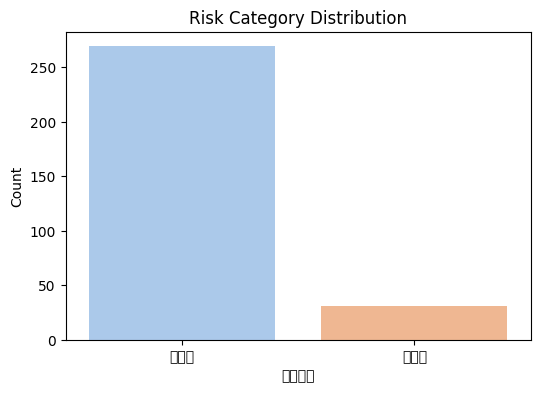

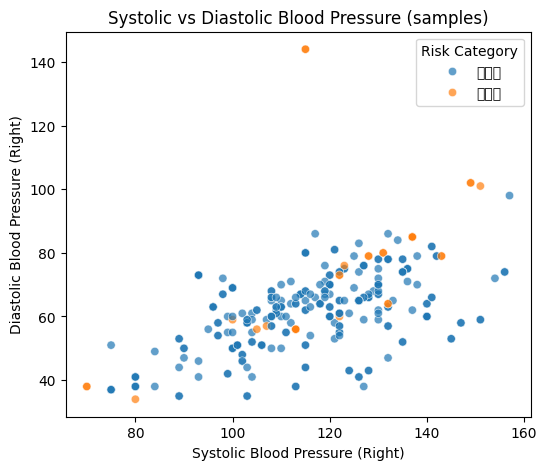

In [41]:
# 绘制并保存分布图与血压散点图
vc = df['风险类别'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=vc.index, y=vc.values, palette='pastel')
plt.title('Risk Category Distribution')
plt.ylabel('Count')
plt.savefig('fig_distribution.png', bbox_inches='tight')
print('Saved fig_distribution.png')
# 重命名列（如果需要）
df_renamed = df.rename(columns={
    '右侧收缩压': 'Systolic_BP_Right',
    '右侧舒张压': 'Diastolic_BP_Right',
    '风险类别': 'Risk_Category'
})

if 'Systolic_BP_Right' in df_renamed.columns and 'Diastolic_BP_Right' in df_renamed.columns:
    plt.figure(figsize=(6,5))
    sns.scatterplot(data=df_renamed, x='Systolic_BP_Right', y='Diastolic_BP_Right', 
                    hue='Risk_Category', alpha=0.7)
    plt.xlabel('Systolic Blood Pressure (Right)')
    plt.ylabel('Diastolic Blood Pressure (Right)')
    plt.title('Systolic vs Diastolic Blood Pressure (samples)')
    plt.legend(title='Risk Category')
    plt.savefig('fig_bp_scatter.png', bbox_inches='tight')
    print('Saved fig_bp_scatter.png')


In [42]:
# 保存中间产物用于建模 notebook
df.to_csv('cleaned_full.csv', index=False, encoding='utf-8')
df[['风险类别']].value_counts().to_csv('risk_counts.csv', header=['count'])
print('Saved cleaned_full.csv and risk_counts.csv')

Saved cleaned_full.csv and risk_counts.csv


---
下一步：打开 `modeling.ipynb`（建模与评估），该 notebook 将读取 `cleaned_full.csv` 并继续特征处理、训练与评估。